# seegg_ usage tutorial 
for synthetic EEG generation

#### 1. Imports and basic setup

In [31]:
# Import basic libraries
import os
import json
from pathlib import Path
import numpy as np
import torch
import pickle
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
import logging
import warnings
import logging
from typing import Union

# Get core classes and functions
from ecog_gan import Generator, WindowCritic, ECoGDataLoader, Trainer, load_config
from ecog_gan.utils import setup_device, create_output_directories, plot_signals
from ecog_gan.utils.visualization import get_example_2d

# To silent warnings and logs
#logging.basicConfig(level=logging.INFO)
#logger = logging.getLogger(__name__)
#warnings.filterwarnings("ignore")
#logging.getLogger().setLevel(logging.ERROR)
#os.environ["PYTHONWARNINGS"] = "ignore"
#os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"  # if TensorFlow is installed

# Set Arial as default font
plt.rcParams['font.family'] = 'Arial'




#### 2. Paths, basic hyperparameters, and config loading

In [7]:
# Paths
real_data   = Path("/Users/is/seegg/data/5_real_examples.pkl")           # preprocessed ECoG segments
CONFIG_PATH = Path("/Users/is/seegg/configs/default_config.yaml") # Change to ./configs/default_config.yaml
OUTPUT_DIR  = Path("/Users/is/seegg/training_results")

# Core training hyperparameters 
NUM_EPOCHS   = 500        # you can start with a smaller value (e.g. 10–50) for quick tests
BATCH_SIZE   = 64         
GPU_ID       = 0          # set to None to force CPU

# Optimizer and critic configuration
GENERATOR_LR = 5e-5
CRITIC_LR    = 1e-5
N_CRITIC     = 5           # critic updates per generator update
USE_PE       = True        # positional encoding in the critic


# Load and minimally override config 
config = load_config(str(CONFIG_PATH))

config["training"]["num_epochs"] = NUM_EPOCHS
config["data"]["batch_size"]     = BATCH_SIZE

# Optimizer settings
config.setdefault("optimizer", {})
config["optimizer"].setdefault("generator", {})
config["optimizer"].setdefault("critic", {})

config["optimizer"]["generator"]["lr"]     = GENERATOR_LR
config["optimizer"]["generator"]["betas"]  = (0.5, 0.999)
config["optimizer"]["critic"]["lr"]        = CRITIC_LR
config["optimizer"]["critic"]["betas"]     = (0.5, 0.999)

# Training/model tweaks
config["training"]["critic_iterations"]       = N_CRITIC
config["model"]["critic"]["use_PE"]           = USE_PE
config["loss"]["gradient_penalty_weight"]     = 10.0
config["loss"]["drift_penalty"]               = 0.001

if GPU_ID is not None:
    config["device"]["gpu_id"] = GPU_ID

# (optional) Print a compact view of the most relevant config parts
print("Training config summary:")
print(json.dumps({
    "num_epochs": config["training"]["num_epochs"],
    "batch_size": config["data"]["batch_size"],
    "generator_lr": config["optimizer"]["generator"]["lr"],
    "critic_lr": config["optimizer"]["critic"]["lr"],
    "critic_iterations": config["training"]["critic_iterations"],
    "use_PE": config["model"]["critic"]["use_PE"]
}, indent=2))


Training config summary:
{
  "num_epochs": 500,
  "batch_size": 64,
  "generator_lr": 5e-05,
  "critic_lr": 1e-05,
  "critic_iterations": 5,
  "use_PE": true
}


#### 3. Device setup and output directories

In [12]:
device = setup_device(config["device"].get("gpu_id"))
print(f"Using device: {device}")

output_paths = create_output_directories(str(OUTPUT_DIR))
timestamped_output_dir = Path(output_paths["base"])
config["monitoring"]["output_dir"] = str(timestamped_output_dir)

print(f"All results will be saved under: {timestamped_output_dir}")


Using device: mps
All results will be saved under: training_results/ecog_gan_2511_1031


#### 4. Load training data

In [8]:
# Load data 
data_loader = ECoGDataLoader(
    data_path=str(real_data),
    seq_len=config["data"]["seq_len"],
    batch_size=config["data"]["batch_size"],
    shuffle=config["data"]["shuffle"],
    num_workers=config["data"]["num_workers"],
)

data_info    = data_loader.get_data_info()
sample_shape = data_loader.get_sample_shape()  # (channels, samples)

print("Data info:", data_info)
print("Sample shape (channels, samples):", sample_shape)
print("Number of batches per epoch:", len(data_loader))


Data info: {'format': 'array_3d', 'type': 'ndarray', 'total_samples': 5, 'shapes': [], 'channels_info': {}, 'sample_lengths': [], 'shape': (5, 20, 1536), 'num_channels': 20, 'sample_length': 1536}
Sample shape (channels, samples): torch.Size([20, 1536])
Number of batches per epoch: 5


#### 5. Initialize Generator, Critic, and Trainer

In [14]:
# Target shape for the generator output (1, channels, samples)
target_shape = (1, sample_shape[0], sample_shape[1])

generator = Generator(
    latent_dim   = config["model"]["generator"]["latent_dim"],
    out_channels = config["model"]["generator"]["out_channels"],
    target_shape = target_shape,
    use_attention    = config["model"]["generator"]["use_attention"],
    attention_config = config["model"]["generator"]["attention_config"],
)

critic = WindowCritic(
    time_window    = config["model"]["critic"]["time_window"],
    fs             = config["data"]["sampling_rate"],
    channels       = sample_shape[0],
    embedding_dim  = config["model"]["critic"]["embedding_dim"],
    max_window_nums = config["model"]["critic"]["max_window_nums"],
    use_PE         = config["model"]["critic"]["use_PE"],
    attention_config = config["model"]["critic"]["attention_config"],
)

print(f"Generator parameters: {sum(p.numel() for p in generator.parameters()):,}")
print(f"Critic parameters:    {sum(p.numel() for p in critic.parameters()):,}")

trainer = Trainer(
    generator = generator,
    critic    = critic,
    config    = config,
    device    = device,
)

print("Trainer initialized.")


Generator parameters: 2,941,120
Critic parameters:    644,149
Trainer initialized.


#### 6. Train the model

In [15]:
print(f"Starting training for {NUM_EPOCHS} epochs...")
trainer.train(
    dataloader = data_loader.get_dataloader(),
    num_epochs = NUM_EPOCHS,
)
print("Training finished.")


Starting training for 500 epochs...
Training finished.


#### 7. Generate synthetic samples

In [1]:
# Number of synthetic samples to generate
n_samples = 8

with torch.no_grad():
    synthetic_batch = trainer.generate_samples(n_samples)

print("Synthetic batch shape:", synthetic_batch.shape)

# Take first synthetic example
synthetic_example = synthetic_batch[0].detach().cpu().numpy().squeeze()

print("synthetic_example shape:", synthetic_example.shape)


NameError: name 'torch' is not defined

#### 8. Save synthetic samples

In [19]:
generated_dir = Path(output_paths["generated_data"])
generated_dir.mkdir(parents=True, exist_ok=True)

synthetic_path = generated_dir / "synthetic_samples_test1.pkl"

with open(synthetic_path, "wb") as f:
    pickle.dump(synthetic_batch.cpu().numpy(), f)

print(f"Synthetic samples saved to: {synthetic_path}")


Synthetic samples saved to: training_results/ecog_gan_2511_1031/generated_data/synthetic_samples_test1.pkl


#### 9. Visualize real vs synthetic signals

Real batch shape: torch.Size([5, 20, 1536])
Generated batch shape: (8, 20, 1536)


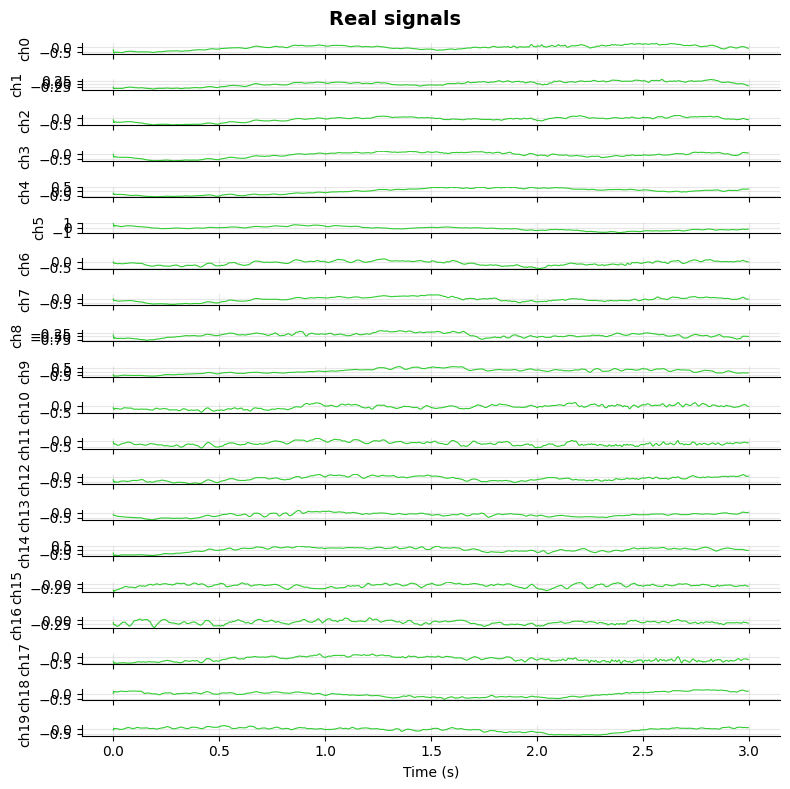

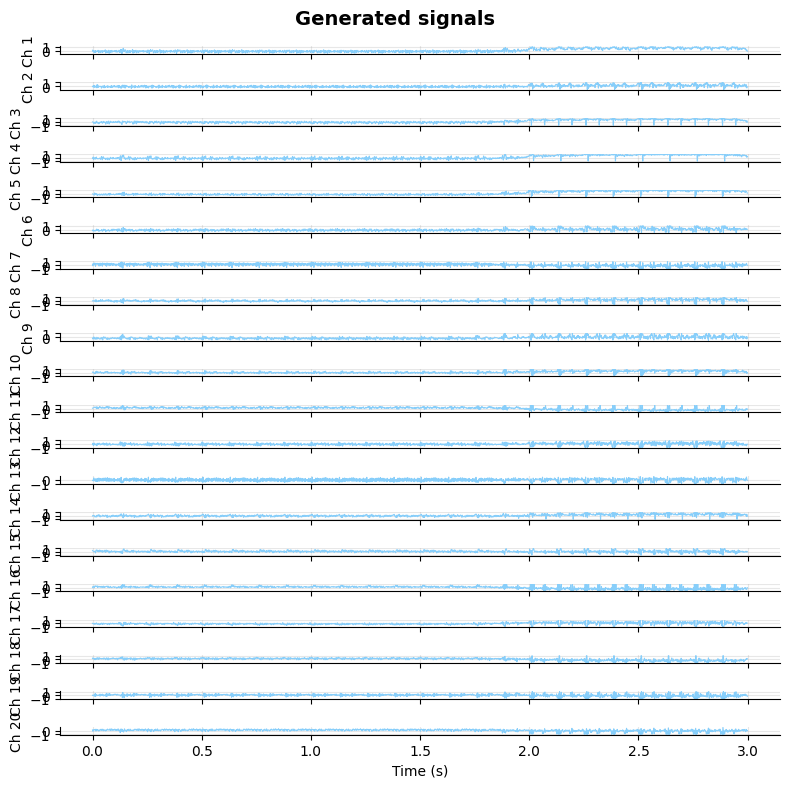

In [29]:
%matplotlib inline

# Real signals

dl = data_loader.get_dataloader()
batch = next(iter(dl))
real_batch = batch[0] if isinstance(batch, (list, tuple)) else batch
print("Real batch shape:", real_batch.shape)

real_example = get_example_2d(real_batch, example_idx=0)  # first real sample
channel_names = [f"ch{i}" for i in range(real_example.shape[0])]

plot_signals(
    real_example,
    sampling_rate=512,
    channels=channel_names,
    title="Real signals",
    figsize=(8, 8),  # taller so 20 subplots fit nicely
    color='limegreen'
)

# Open generated signals

# Open pickle file
synthetic_path =  "/Users/is/seegg/training_results/ecog_gan_2511_1031/generated_data/synthetic_samples_test1.pkl"
with open(synthetic_path, "rb") as f:
    synthetic_batch = pickle.load(f)

print("Generated batch shape:", synthetic_batch.shape)

gen_example = get_example_2d(synthetic_batch, example_idx=2)  # third generated sample
plot_signals(
    gen_example,
    sampling_rate=512,
    title="Generated signals",
    figsize=(8,8),
    color='lightskyblue'
)

plt.show()

#### 9. XAI methods visualization

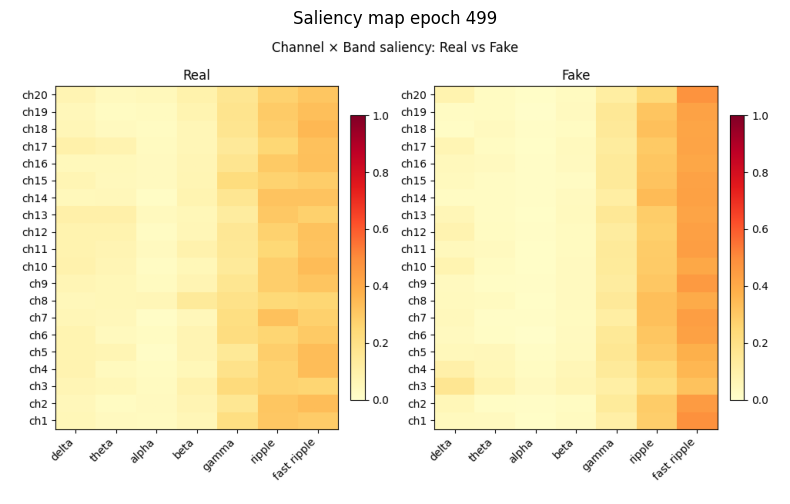

In [27]:
# Open XAI image
xai_image_path = "/Users/is/seegg/training_results/ecog_gan_2511_1031/plots/chan_band_real_fake_epoch_499.png"

img = matplotlib.image.imread(xai_image_path)

plt.figure(figsize=(8, 6))
plt.imshow(img)               # `img` should already contain the image loaded from `xai_image_path`
plt.axis('off')               # hide axis ticks
plt.title("Saliency map epoch 499")
plt.tight_layout()
plt.show()

#### 10. Synthetic data evaluation: dense signals

For fidelity, diversity and privacy sparse signals evaluation please visit our repositiory seege_

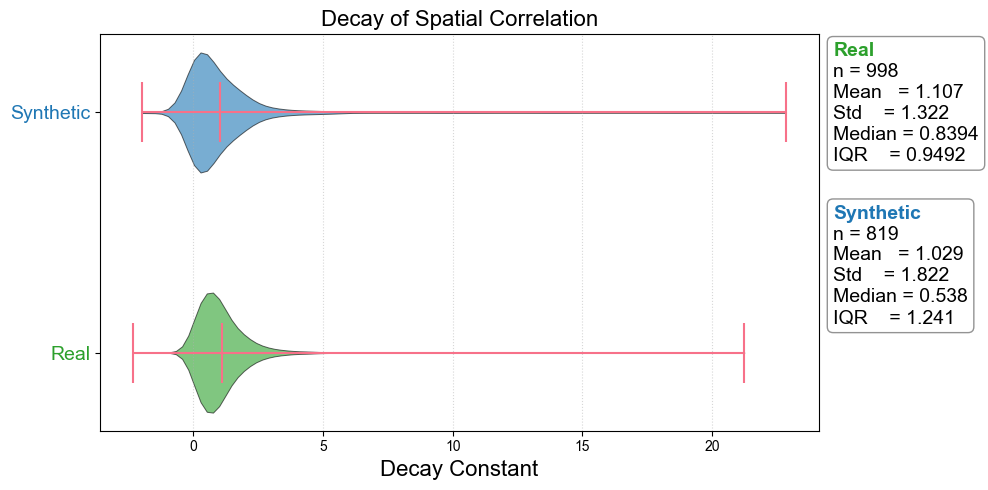

In [34]:
# --- load data ---
correlations = pd.read_pickle(
    "/Users/is/seegg/data/decay_constants.pkl"
)

real = np.asarray(correlations['real_decay'], dtype=float)
synt = np.asarray(correlations['synthetic_decay'], dtype=float)

data   = [real, synt]
labels = ['Real', 'Synthetic']
colors = ['#2ca02c', '#1f77b4']  # green, blue

# --- figure ---
fig, ax = plt.subplots(figsize=(10, 5))
# Violin plot (horizontal orientation)
parts = ax.violinplot(
      data,
      vert=False,  # horizontal orientation
      showmeans=True,
      showmedians=False,
      showextrema=True
)

# Color violins
for i, body in enumerate(parts['bodies']):
      body.set_facecolor(colors[i])
      body.set_edgecolor('black')
      body.set_alpha(0.6)
      body.set_linewidth(0.7)

# --- Stats boxes: colored label, black stats, no overlap ---
props = dict(boxstyle='round', facecolor='white', alpha=0.85, edgecolor='gray')

x_anchor = 1.02   # right of axes
y_anchor = 0.98   # start near top
line = 0.055      # line height in axes coords
gap  = 0.08       # gap between boxes

for label, d, color in zip(labels, data, colors):
      stats_text = (
            "\n"
            f"n = {len(d)}\n"
            f"Mean   = {np.mean(d):.4g}\n"
            f"Std    = {np.std(d, ddof=0):.4g}\n"
            f"Median = {np.median(d):.4g}\n"
            f"IQR    = {np.percentile(d,75)-np.percentile(d,25):.4g}"
      )
      ax.text(x_anchor, y_anchor, stats_text, transform=ax.transAxes,
                  va='top', ha='left', fontsize=14, color='black', bbox=props)
      ax.text(x_anchor, y_anchor, label, transform=ax.transAxes,
                  va='top', ha='left', fontsize=14, fontweight='bold', color=color)
      y_anchor -= (line * 6 + gap)

# --- Axis cosmetics ---
ax.set_yticks([1, 2])
ax.set_yticklabels(labels, fontsize=14)
for label, color in zip(ax.get_yticklabels(), colors):
      label.set_color(color)

ax.set_xlabel('Decay Constant', fontsize=16)
ax.set_title('Decay of Spatial Correlation', fontsize=16)
ax.grid(True, axis='x', ls=':', alpha=0.5)

plt.tight_layout()
plt.show()